# Visualizations

Reference 2: https://evalf22.classes.andrewheiss.com/example/diff-in-diff.html 

"My hands, they shake, my head, it spins
Oh, Brooklyn, Brooklyn, take me in" - Avett Brothers

#### Loading things

In [79]:
setwd("/Users/Local/statsproject")

In [80]:
source("src/functions_and_things.r")

load_libraries()

In [81]:
nyc_blue   = "#0062CF"
nyc_orange = "#EB6800"

In [82]:
df_daily <- read.csv("data/clean/daily_ridership.csv")
head(df_daily)

df_daily |> mutate(time = ifelse(date > "2025-01-01" , 1, 0)) -> df_daily

,date,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-03,Bronx,80011
2,2024-06-03,Brooklyn,259226
3,2024-06-03,Manhattan,314840
4,2024-06-03,Queens,173652
5,2024-06-04,Bronx,83027
6,2024-06-04,Brooklyn,282527


In [83]:
df_weekly <- read.csv("data/clean/weekly_ridership.csv")
df_weekly$week <- as.Date(df_weekly$week)

In [84]:
df_ma <- read.csv("data/clean/smooth.csv")
df_ma$week <- as.Date(df_ma$week)

### Time series things

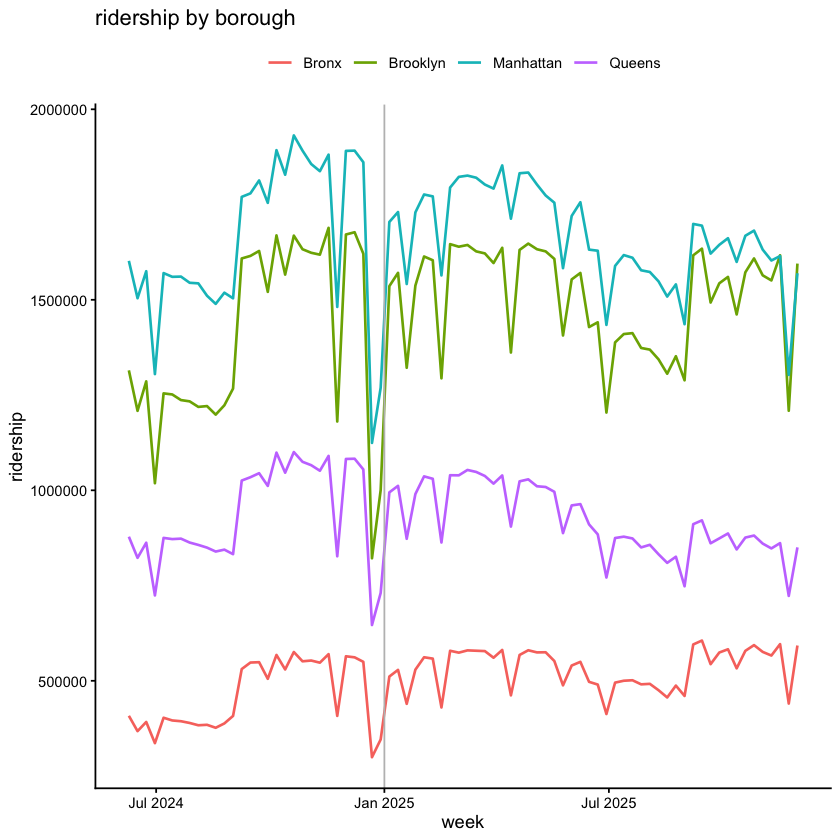

In [85]:
df_weekly |> filter(week > "2024-06-05" & week < "2025-12-07") |> 
ggplot(aes(x = week, y = ridership, group = borough, color = as.factor(borough))) + 
    geom_line(lwd = .75) + theme_classic() +
    theme(legend.position= "top",
          legend.title = element_blank()) + 
    geom_vline(xintercept = as.Date("2025-01-01"), color = "grey") + 
    labs(title = "ridership by borough") +
    scale_x_date(date_labels = "%b %Y")

`geom_smooth()` using formula = 'y ~ x'


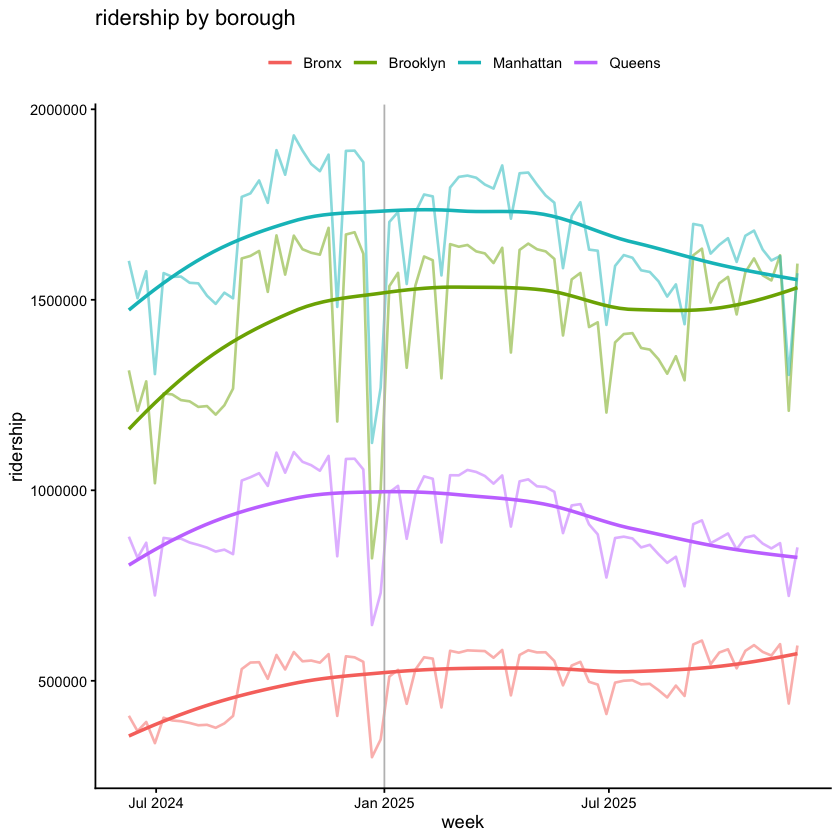

In [86]:
df_weekly |> filter(week > "2024-06-05" & week < "2025-12-07") |> 
ggplot(aes(x = week, y = ridership, group = borough, color = as.factor(borough))) + 
    geom_line(lwd = .75, alpha = .5) + theme_classic() +
    theme(legend.position= "top",
          legend.title = element_blank()) + 
    geom_vline(xintercept = as.Date("2025-01-01"), color = "grey") + 
    labs(title = "ridership by borough") +
    scale_x_date(date_labels = "%b %Y") +
    geom_smooth(method = "loess", se =FALSE)

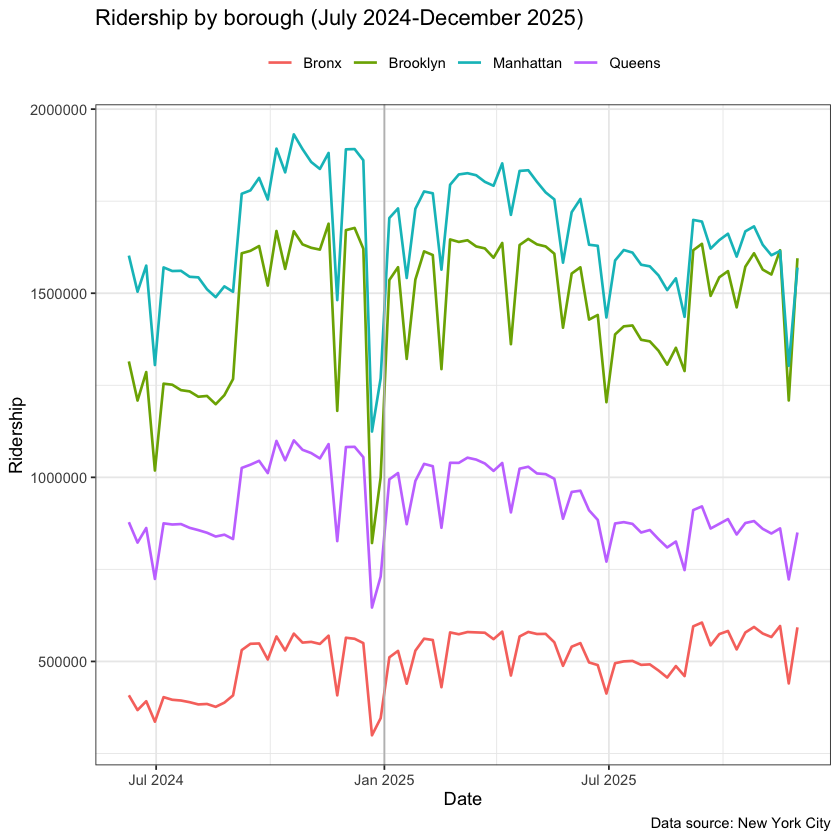

In [87]:
df_ma |> filter(week > "2024-06-05" & week < "2025-12-02") |> 
ggplot(aes(x = week, y = ridership, group = borough, color = as.factor(borough))) + 
    geom_line(lwd = .75) + theme_bw() +
    theme(legend.position= "top",
          legend.title = element_blank()) + 
    geom_vline(xintercept = as.Date("2025-01-01"), color = "grey") + 
    labs(title = "Ridership by borough (July 2024-December 2025)",
            x = "Date", y = "Ridership",
            caption = "Data source: New York City") +
    scale_x_date(date_labels = "%b %Y") 


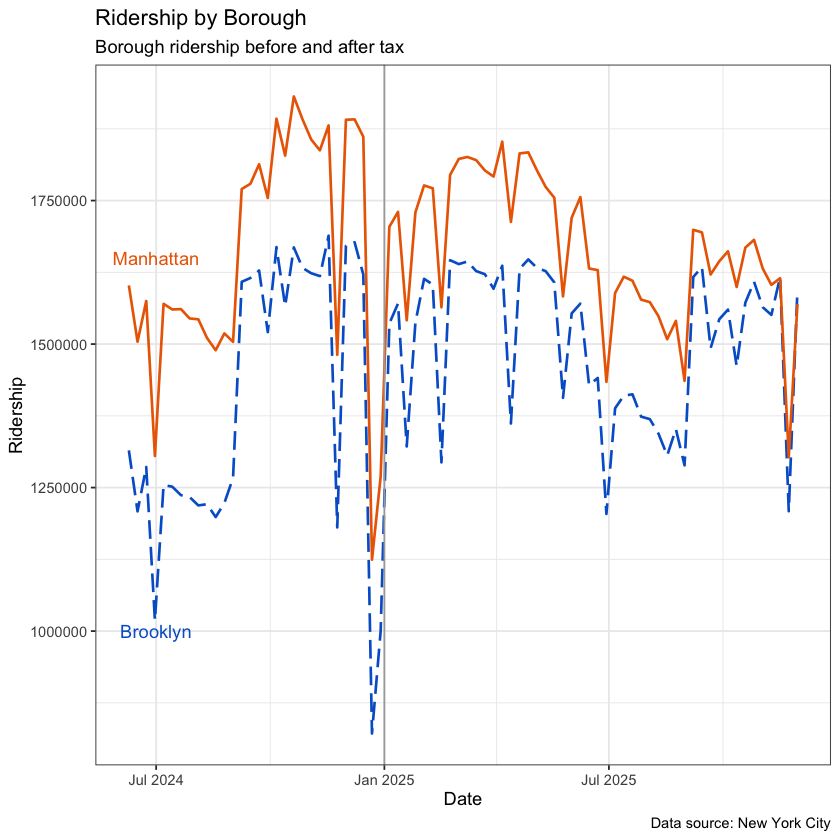

In [88]:
df_ma |> filter(week > "2024-06-05" & week < "2025-12-05") |> 
filter(borough == "Manhattan" | borough == "Brooklyn") |> 
ggplot(aes(x = week, y = ridership, group = borough, lty = as.factor(borough), color = as.factor(borough))) + 
    scale_linetype_manual(values = c(
        "Brooklyn" = "longdash", "Manhattan" = "solid")) + 
    scale_color_manual(values = c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange)) + 
    geom_line(lwd = .75) + 
    theme_bw() +
    theme(legend.position= "none",
          legend.title = element_blank()) + 
    geom_vline(xintercept = as.Date("2025-01-01"), color = "darkgrey") + 
    labs(title = "Ridership by Borough", y = "Ridership", x = "Date",
        subtitle= "Borough ridership before and after tax", 
        caption = "Data source: New York City") +
    scale_x_date(date_labels = "%b %Y") +
    annotate("text", x = as.Date("2024-07-01"), y = 1000000, label = "Brooklyn", color = nyc_blue) +
    annotate("text", x = as.Date("2024-07-01"), y = 1650000, label = "Manhattan", color = nyc_orange)

`geom_smooth()` using formula = 'y ~ x'


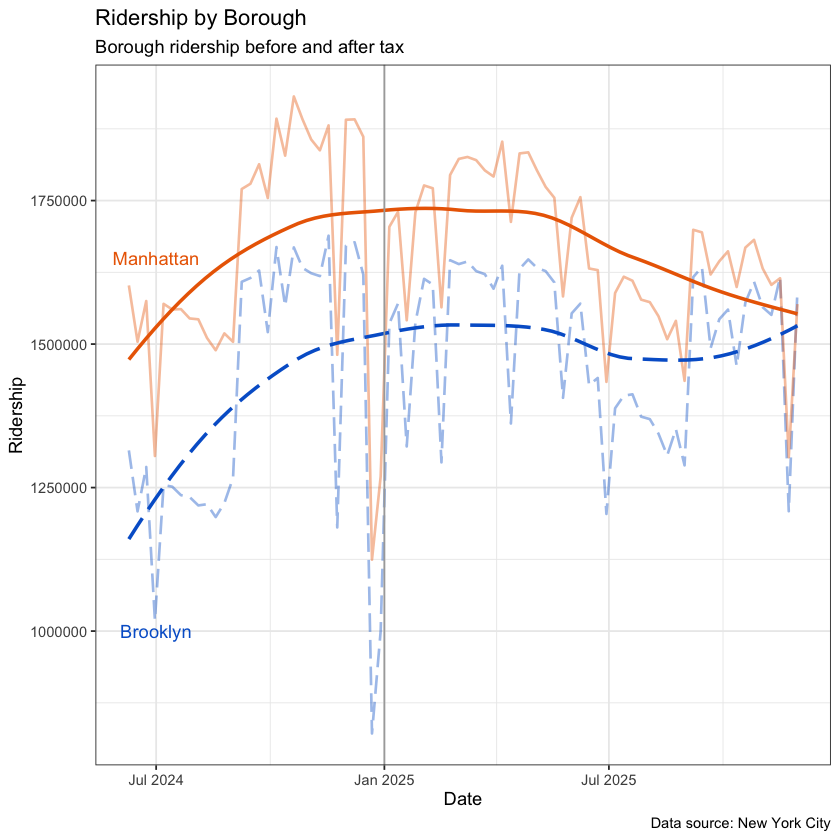

In [89]:
df_ma |> filter(week > "2024-06-05" & week < "2025-12-05") |> 
filter(borough == "Manhattan" | borough == "Brooklyn") |> 
ggplot(aes(x = week, y = ridership, group = borough, lty = as.factor(borough), color = as.factor(borough))) + 
    scale_linetype_manual(values = c(
        "Brooklyn" = "longdash", "Manhattan" = "solid")) + 
    scale_color_manual(values = c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange)) + 
    geom_line(lwd = .75, alpha = .4) +
    geom_smooth(method = "loess", se = FALSE) +
    theme_bw() +
    theme(legend.position= "none",
          legend.title = element_blank()) + 
    geom_vline(xintercept = as.Date("2025-01-01"), color = "darkgrey") + 
    labs(title = "Ridership by Borough", y = "Ridership", x = "Date",
        subtitle= "Borough ridership before and after tax", 
        caption = "Data source: New York City") +
    scale_x_date(date_labels = "%b %Y") +
    annotate("text", x = as.Date("2024-07-01"), y = 1000000, label = "Brooklyn", color = nyc_blue) +
    annotate("text", x = as.Date("2024-07-01"), y = 1650000, label = "Manhattan", color = nyc_orange)

### walk through

ref: https://evalf22.classes.andrewheiss.com/example/diff-in-diff.html

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


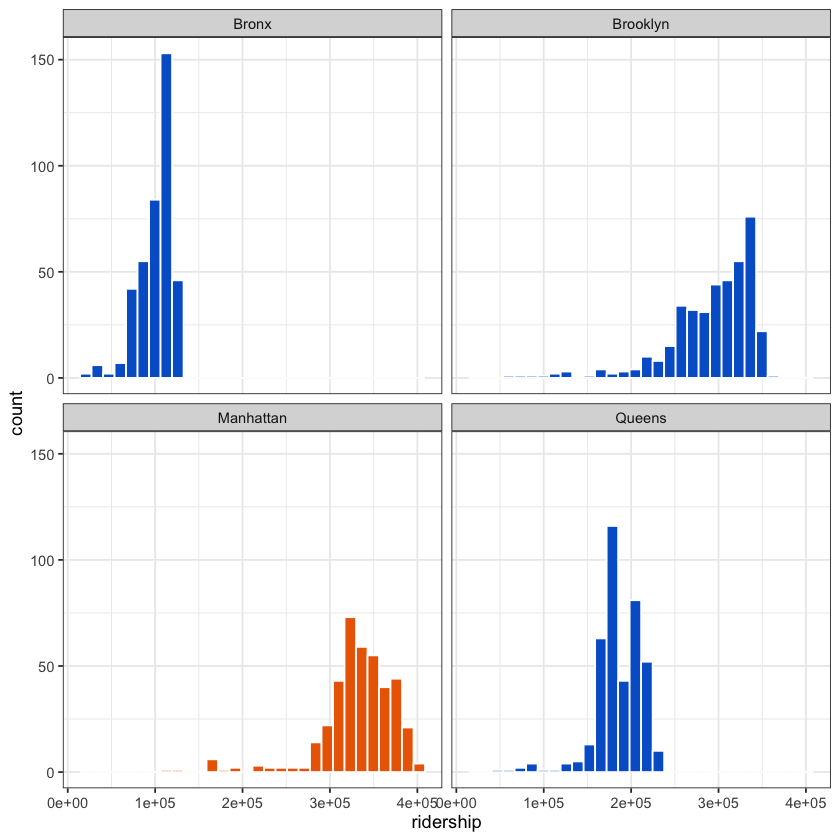

In [90]:
ggplot(data = df_daily, aes(x = ridership, fill = borough)) +
   geom_histogram(color = "white") + 
   scale_fill_manual(values =  c(
      "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, "Queens" = nyc_blue, "Bronx" = nyc_blue)) + 
   facet_wrap(vars(borough)) + 
   theme_bw() + 
   theme(legend.position = "none")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


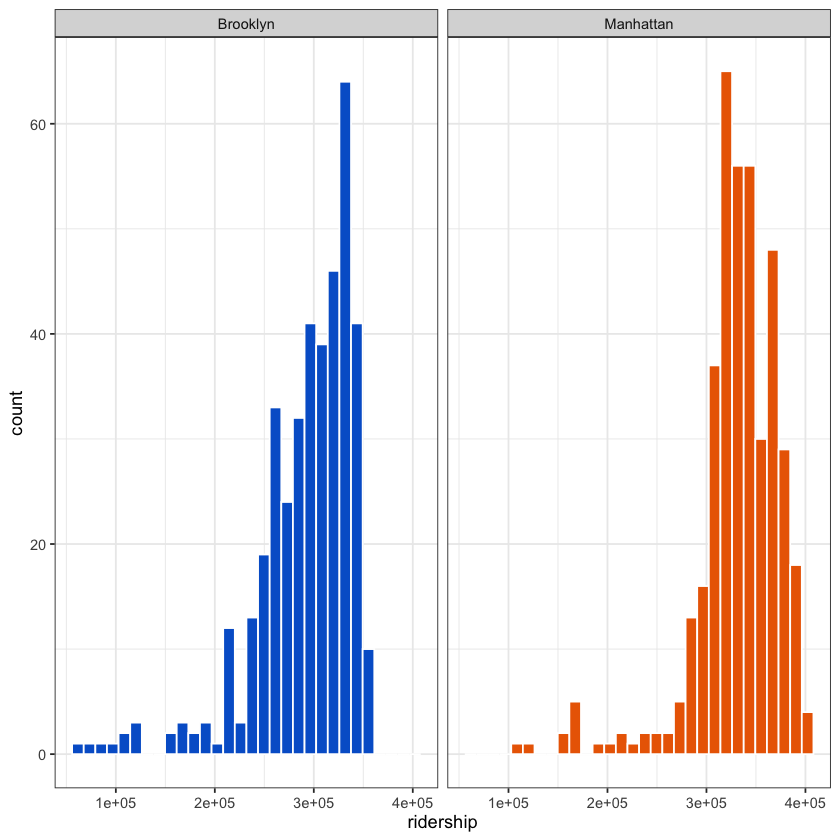

In [91]:
df_daily |> filter(borough == "Brooklyn" | borough == "Manhattan") |> 
ggplot(aes(x = ridership, fill = borough)) +
   geom_histogram(color = "white") + 
   scale_fill_manual(values =  c(
      "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, "Queens" = nyc_blue, "Bronx" = nyc_blue)) + 
   facet_wrap(vars(borough)) + 
   theme_bw() + 
   theme(legend.position = "none")

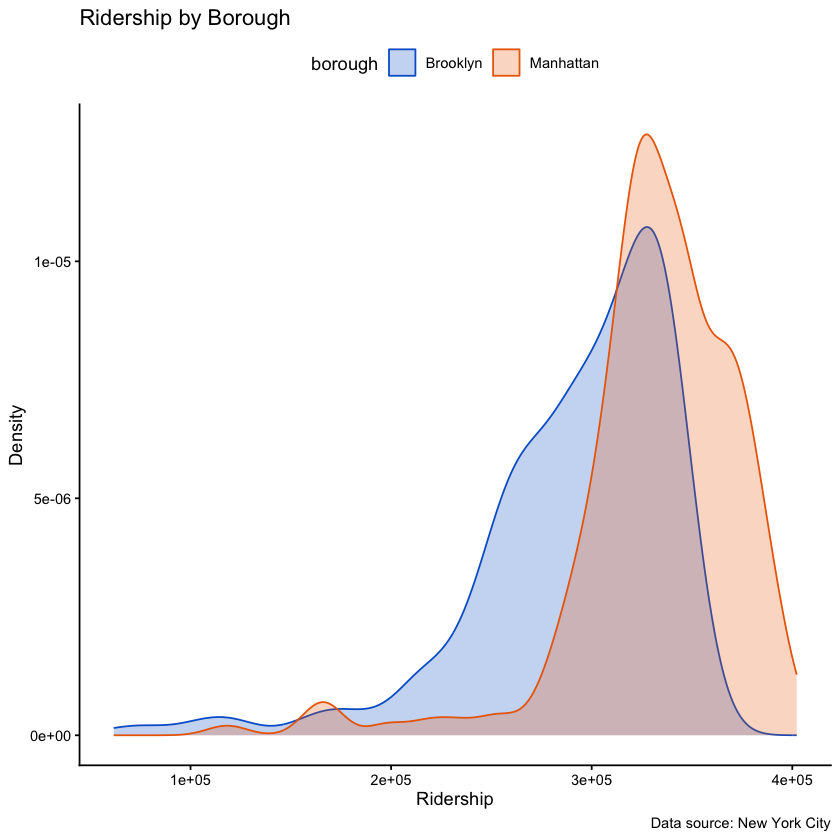

In [92]:
# ref 1 
df_daily |> filter(borough == "Brooklyn" | borough == "Manhattan") |> 
    ggplot(aes(x=ridership, fill=borough, color = borough)) + geom_density(alpha=0.25) +
    theme_classic() + theme(legend.position = "top") + 
    scale_fill_manual(values =  c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, 
        "Queens" = nyc_blue, "Bronx" = nyc_blue)) +
    scale_color_manual(values =  c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, 
        "Queens" = nyc_blue, "Bronx" = nyc_blue)) +
    labs(title = "Ridership by Borough", y = "Density", x = "Ridership",
        caption = "Data source: New York City") 

In [110]:
head(df_daily)

,date,borough,ridership,time
,<chr>,<chr>,<int>,<dbl>
1,2024-06-03,Bronx,80011,0
2,2024-06-03,Brooklyn,259226,0
3,2024-06-03,Manhattan,314840,0
4,2024-06-03,Queens,173652,0
5,2024-06-04,Bronx,83027,0
6,2024-06-04,Brooklyn,282527,0


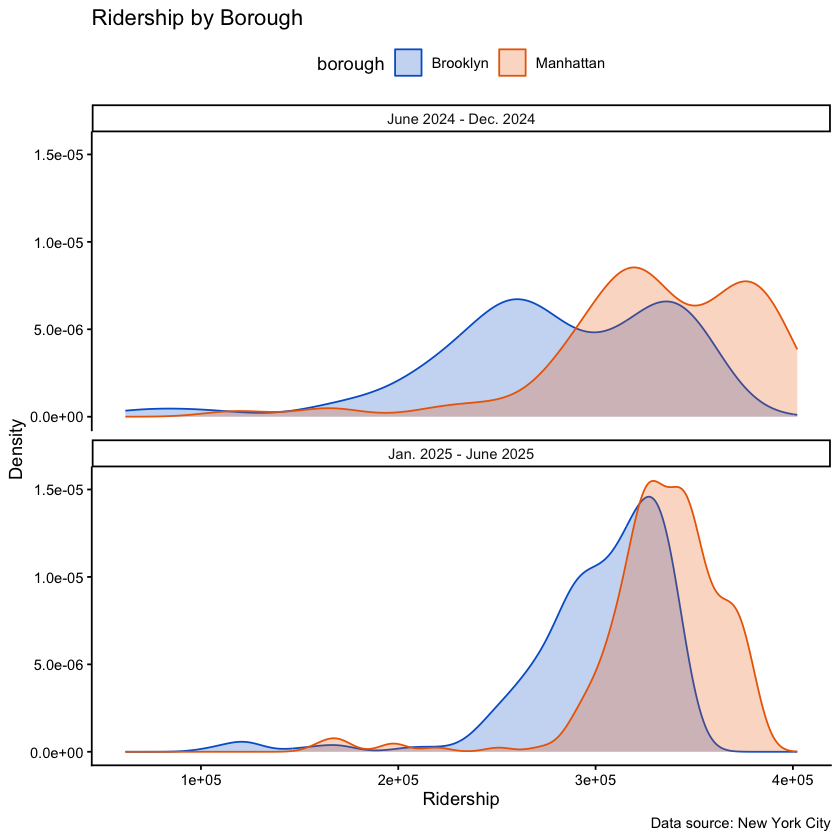

In [116]:
# ref 1 
df_daily |> filter(borough == "Brooklyn" | borough == "Manhattan") |> 
            mutate(after_2025 = factor(time, labels = c("June 2024 - Dec. 2024", "Jan. 2025 - June 2025"))) |>
    ggplot(aes(x=ridership, fill=borough, color = borough)) + geom_density(alpha=0.25) +
    theme_classic() + theme(legend.position = "top") + 
    scale_fill_manual(values =  c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, 
        "Queens" = nyc_blue, "Bronx" = nyc_blue)) +
    scale_color_manual(values =  c(
        "Brooklyn" = nyc_blue, "Manhattan" = nyc_orange, 
        "Queens" = nyc_blue, "Bronx" = nyc_blue)) +
    labs(title = "Ridership by Borough", y = "Density", x = "Ridership",
        caption = "Data source: New York City") +
    facet_wrap(~after_2025, nrow = 2)



`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


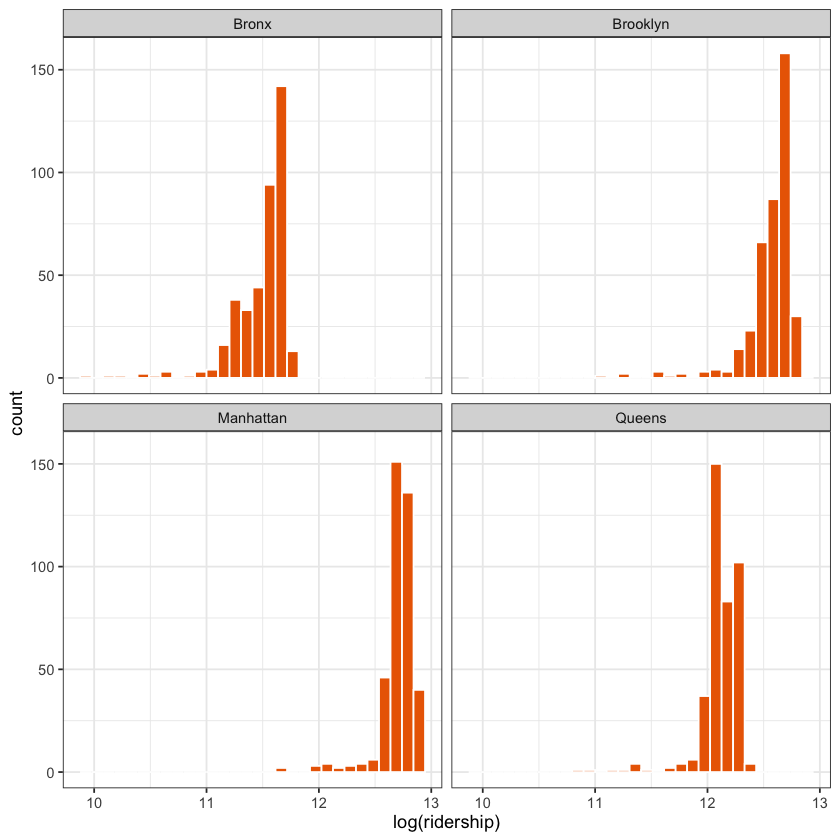

In [93]:
ggplot(data = df_daily, aes(x = log(ridership))) +
 geom_histogram(color = "white", fill = nyc_orange, boundary = 0) + 
    facet_wrap(vars(borough)) + 
    theme_bw()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


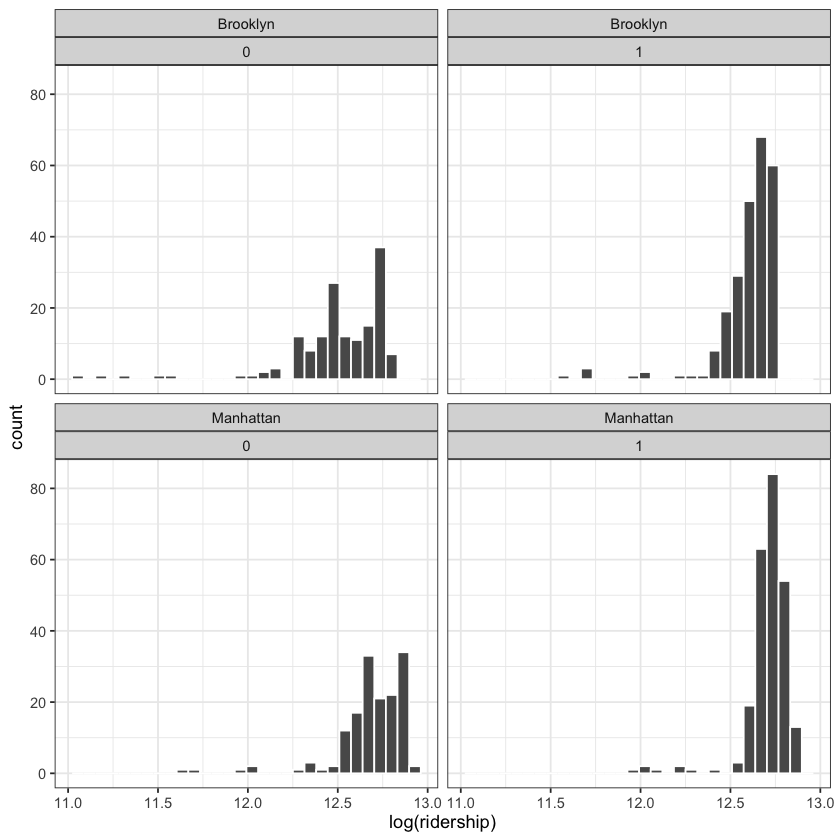

In [94]:
df_daily |> filter(borough == "Manhattan" | borough == "Brooklyn")|>
ggplot(aes(x = log(ridership))) + geom_histogram(color = "white", boundary = 0) + 
    facet_wrap(vars(borough, time)) + 
    theme_bw()

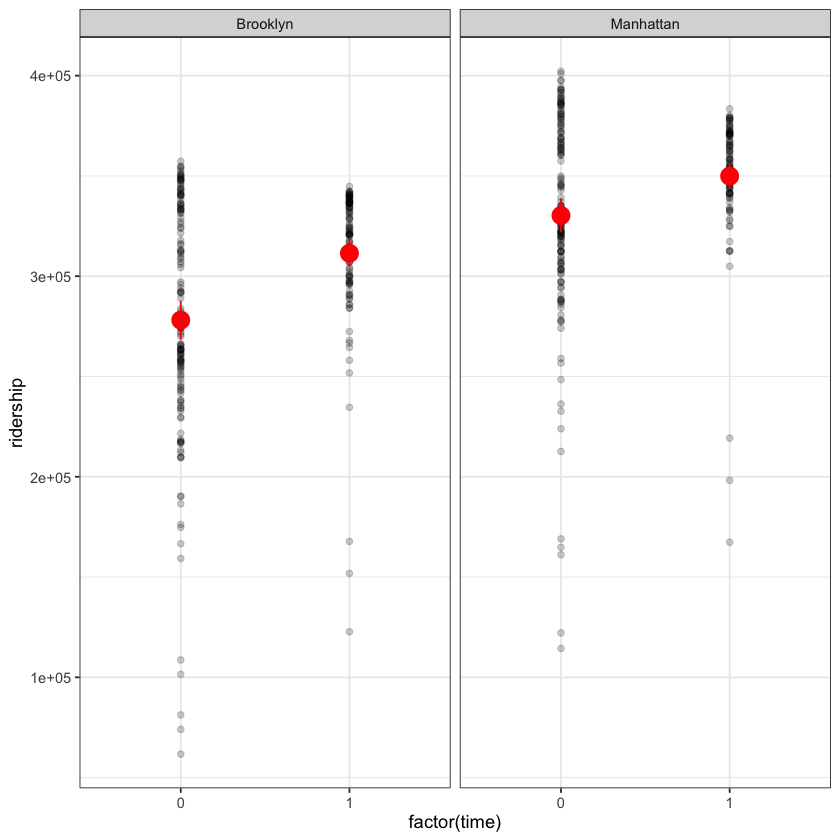

In [95]:
df_daily |> filter(borough == "Manhattan" | borough == "Brooklyn")|>
filter(date < "2025-06-01") |>
ggplot(aes(x = factor(time), y = ridership)) + 
    geom_point(alpha = .2) + 
    stat_summary(geom = "pointrange", fun = "mean", color = "red", size = 1,
                 fun.data = "mean_se", fun.args = list(mult = 1.96)) + 
    facet_wrap(vars(borough)) + 
    theme_bw()

`summarise()` has grouped output by 'borough'. You can override using the
`.groups` argument.


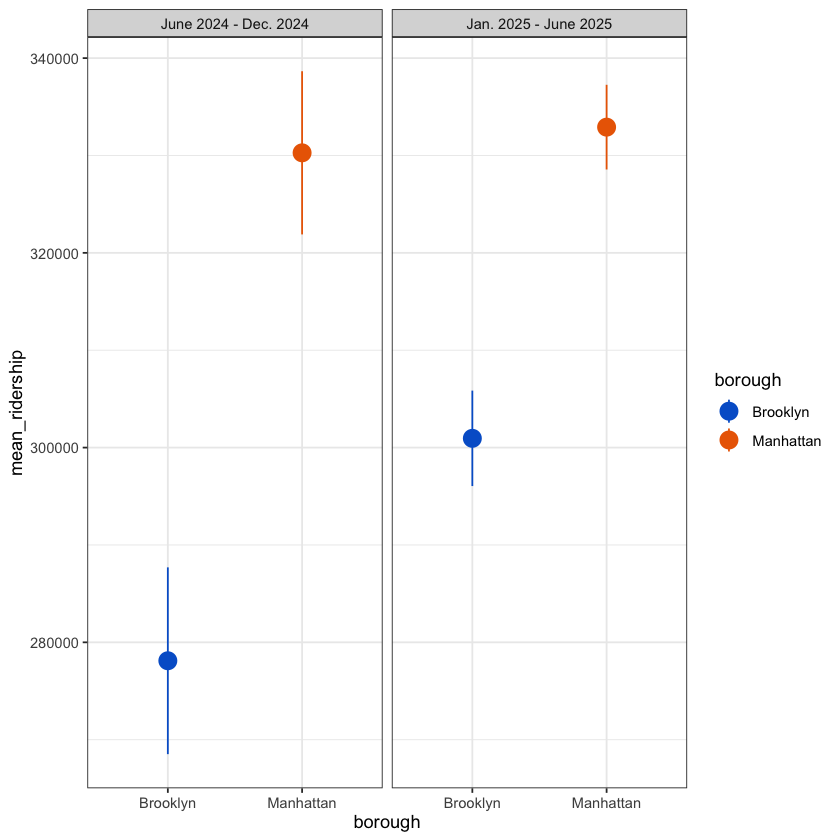

In [96]:
plot_data <- df_daily |>
filter(borough == "Manhattan" | borough == "Brooklyn")|>
  mutate(borough = factor(borough, labels = c("Brooklyn", "Manhattan")),
         after_2025 = factor(time, labels = c("June 2024 - Dec. 2024", "Jan. 2025 - June 2025"))) |>
  group_by(borough, after_2025) %>%
  summarize(mean_ridership = mean(ridership),
            se_ridership = sd(ridership) / sqrt(n()),
            upper = mean_ridership + (1.96 * se_ridership),
            lower = mean_ridership + (-1.96 * se_ridership))

ggplot(plot_data, aes(x = borough, y = mean_ridership, color = borough)) +
  geom_pointrange(aes(ymin = lower, ymax = upper),
                  size = 1) +
  facet_wrap(vars(after_2025)) + 
  scale_color_manual(values = c("Manhattan" = nyc_orange, "Brooklyn" = nyc_blue)) + 
  theme(legend.position = "none", legend.title = element_blank()) + theme_bw()

In [97]:
plot_data

borough,after_2025,mean_ridership,se_ridership,upper,lower
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Brooklyn,June 2024 - Dec. 2024,278107.4,4893.369,287698.4,268516.4
Brooklyn,Jan. 2025 - June 2025,300951.0,2500.748,305852.5,296049.5
Manhattan,June 2024 - Dec. 2024,330273.0,4275.593,338653.1,321892.8
Manhattan,Jan. 2025 - June 2025,332910.3,2218.862,337259.3,328561.4


`summarise()` has grouped output by 'borough'. You can override using the
`.groups` argument.


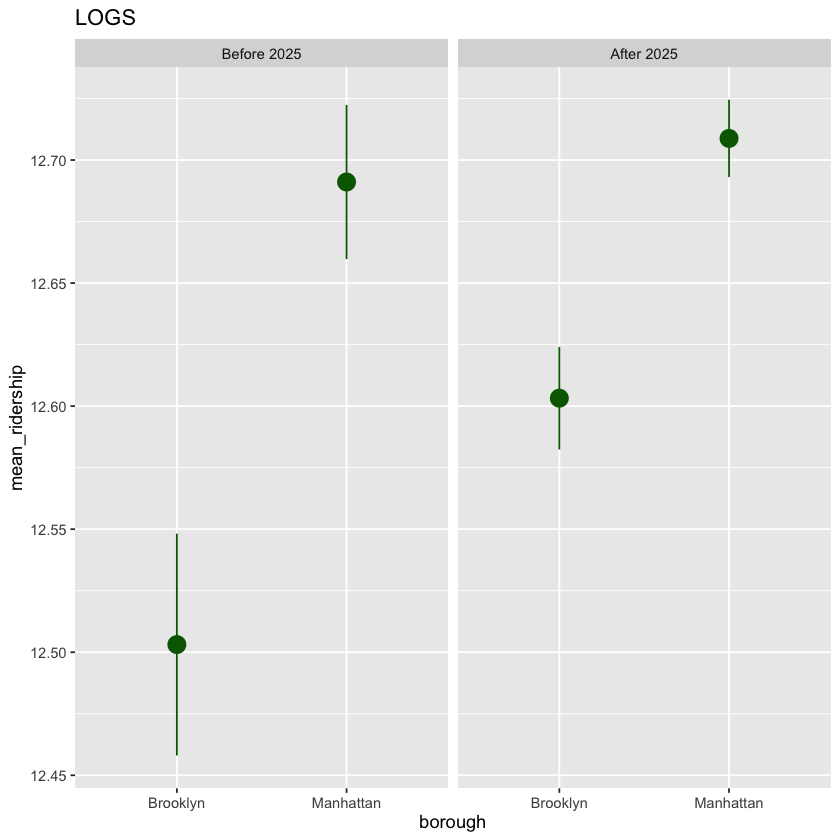

In [98]:
plot_data_log <- df_daily |>
filter(borough == "Manhattan" | borough == "Brooklyn")|>
  # Make these categories instead of 0/1 numbers so they look nicer in the plot
  mutate(borough = factor(borough, labels = c("Brooklyn", "Manhattan")),
         after_2025 = factor(time, labels = c("Before 2025", "After 2025")),
         logridership = log(ridership)) |>
  group_by(borough, after_2025) %>%
  summarize(mean_ridership = mean(logridership),
            se_ridership = sd(logridership) / sqrt(n()),
            upper = mean_ridership + (1.96 * se_ridership),
            lower = mean_ridership + (-1.96 * se_ridership))

ggplot(plot_data_log, aes(x = borough, y = mean_ridership)) +
  geom_pointrange(aes(ymin = lower, ymax = upper),
                  color = "darkgreen", size = 1) +
  facet_wrap(vars(after_2025)) + labs(title = "LOGS")

In [99]:
head(df_daily)

,date,borough,ridership,time
,<chr>,<chr>,<int>,<dbl>
1,2024-06-03,Bronx,80011,0
2,2024-06-03,Brooklyn,259226,0
3,2024-06-03,Manhattan,314840,0
4,2024-06-03,Queens,173652,0
5,2024-06-04,Bronx,83027,0
6,2024-06-04,Brooklyn,282527,0


`summarise()` has grouped output by 'borough'. You can override using the
`.groups` argument.


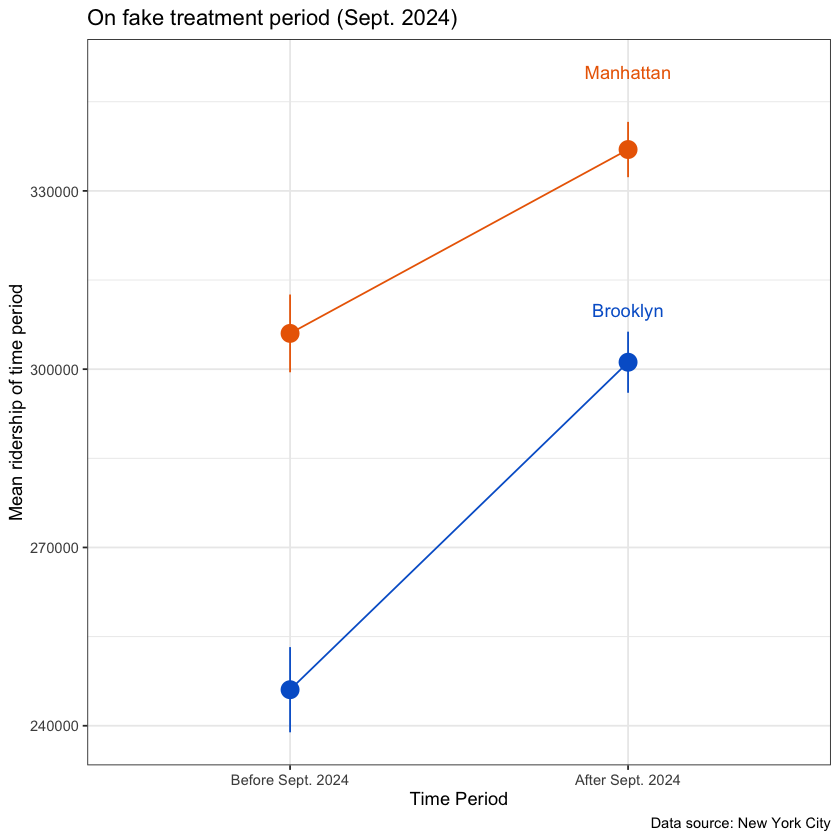

In [134]:
plot_data_fake <- df_daily |>
mutate(after_sept = ifelse(date > "2024-09-01", 1, 0)) |> 
filter(borough == "Manhattan" | borough == "Brooklyn")|>
  # Make these categories instead of 0/1 numbers so they look nicer in the plot
  mutate(borough = factor(borough, labels = c("Brooklyn", "Manhattan")),
         after_sept = factor(after_sept, labels = c("Before Sept. 2024", "After Sept. 2024")))|>
  group_by(borough, after_sept) %>%
  summarize(mean_ridership = mean(ridership),
            se_ridership = sd(ridership) / sqrt(n()),
            upper = mean_ridership + (1.96 * se_ridership),
            lower = mean_ridership + (-1.96 * se_ridership))

ggplot(plot_data_fake, aes(x = after_sept, y = mean_ridership, color = borough)) +
    geom_pointrange(aes(ymin = lower, ymax = upper), size = 1) +
    geom_line(aes(group = borough)) + 
    theme_bw() + theme(legend.position = "none",
                     legend.direction = "horizontal") + 
    labs(x = "Time Period", y = "Mean ridership of time period", 
         title = "On fake treatment period (Sept. 2024)",
         caption = "Data source: New York City") +
    scale_color_manual(values = c("Manhattan" = nyc_orange, "Brooklyn" = nyc_blue)) + 
    annotate("text", x = ("After Sept. 2024"), y = 350000, label = "Manhattan", color = nyc_orange) +
    annotate("text", x = ("After Sept. 2024"), y = 310000, label = "Brooklyn", color = nyc_blue)

`summarise()` has grouped output by 'borough'. You can override using the
`.groups` argument.


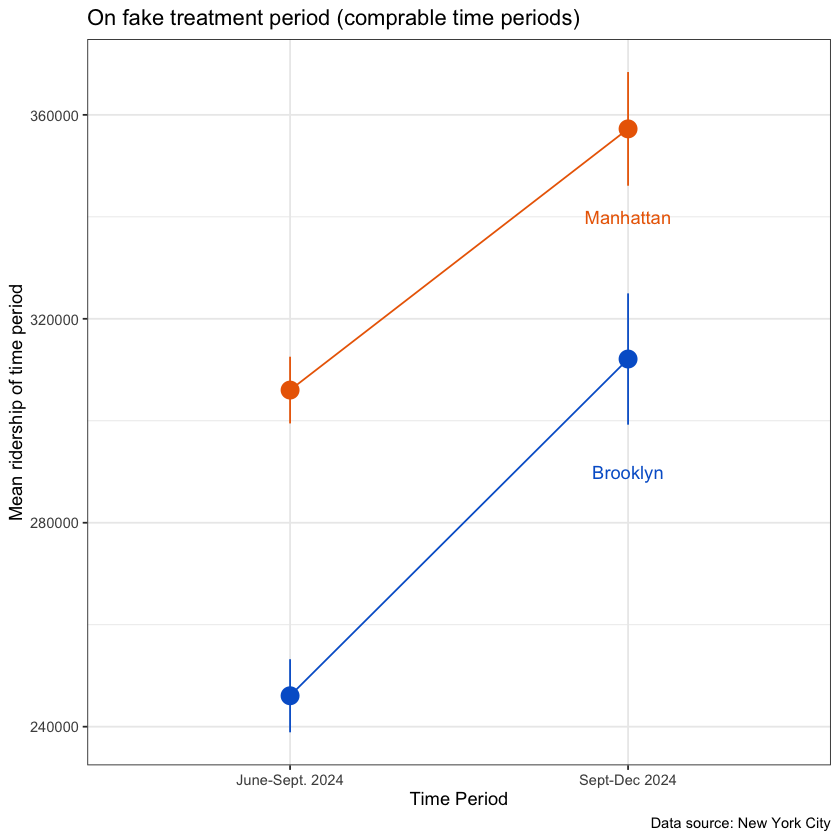

In [133]:
plot_data_fake_eventime <- df_daily |>
mutate(after_sept = ifelse(date > "2024-09-01", 1, 0)) |> 
filter(borough == "Manhattan" | borough == "Brooklyn",
       "2024-06-01" < date & date  < "2024-12-01")|>
  # Make these categories instead of 0/1 numbers so they look nicer in the plot
  mutate(borough = factor(borough, labels = c("Brooklyn", "Manhattan")),
         after_sept = factor(after_sept, labels = c("June-Sept. 2024", "Sept-Dec 2024")))|>
  group_by(borough, after_sept) |> 
  summarize(mean_ridership = mean(ridership),
            se_ridership = sd(ridership) / sqrt(n()),
            upper = mean_ridership + (1.96 * se_ridership),
            lower = mean_ridership + (-1.96 * se_ridership))

ggplot(plot_data_fake_eventime, aes(x = after_sept, y = mean_ridership, color = borough)) +
    geom_pointrange(aes(ymin = lower, ymax = upper), size = 1) +
    geom_line(aes(group = borough)) + 
    theme_bw() + theme(legend.position = "none") + 
    labs(x = "Time Period", y = "Mean ridership of time period", 
    title = "On fake treatment period (comprable time periods)",
    caption = "Data source: New York City") +
    scale_color_manual(values = c("Manhattan" = nyc_orange, "Brooklyn" = nyc_blue))+
    annotate("text", x = ("Sept-Dec 2024"), y = 340000, label = "Manhattan", color = nyc_orange) +
    annotate("text", x = ("Sept-Dec 2024"), y = 290000, label = "Brooklyn", color = nyc_blue)

In [102]:
plot_data_fake

borough,after_sept,mean_ridership,se_ridership,upper,lower
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Brooklyn,Before Sept. 2024,246064.5,3657.763,253233.7,238895.3
Brooklyn,After Sept. 2024,301169.5,2622.904,306310.4,296028.6
Manhattan,Before Sept. 2024,306020.7,3337.623,312562.4,299478.9
Manhattan,After Sept. 2024,336959.5,2373.989,341612.5,332306.4


In [103]:
plot_data

borough,after_2025,mean_ridership,se_ridership,upper,lower
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Brooklyn,June 2024 - Dec. 2024,278107.4,4893.369,287698.4,268516.4
Brooklyn,Jan. 2025 - June 2025,300951.0,2500.748,305852.5,296049.5
Manhattan,June 2024 - Dec. 2024,330273.0,4275.593,338653.1,321892.8
Manhattan,Jan. 2025 - June 2025,332910.3,2218.862,337259.3,328561.4


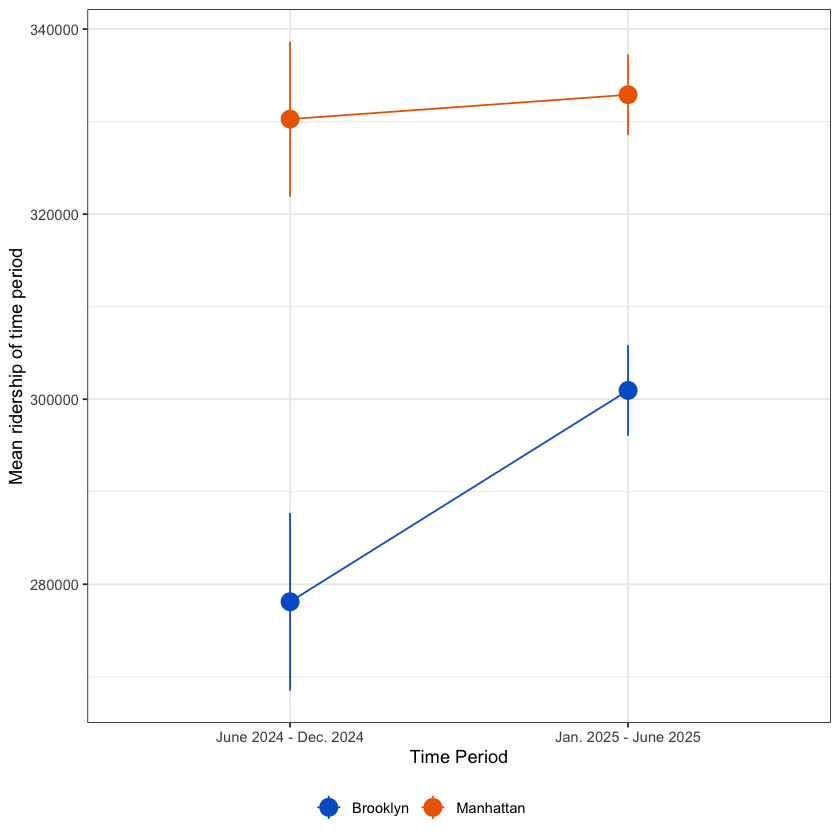

In [104]:
ggplot(plot_data, aes(x = after_2025, y = mean_ridership, color = borough)) +
    geom_pointrange(aes(ymin = lower, ymax = upper), size = 1) +
    geom_line(aes(group = borough)) + 
    theme_bw() + theme(legend.position = "bottom",
                     legend.direction = "horizontal",
                     legend.location = "plot", legend.title = element_blank()) + 
    labs(x = "Time Period", y = "Mean ridership of time period") +
    scale_color_manual(values = c("Manhattan" = nyc_orange, "Brooklyn" = nyc_blue))

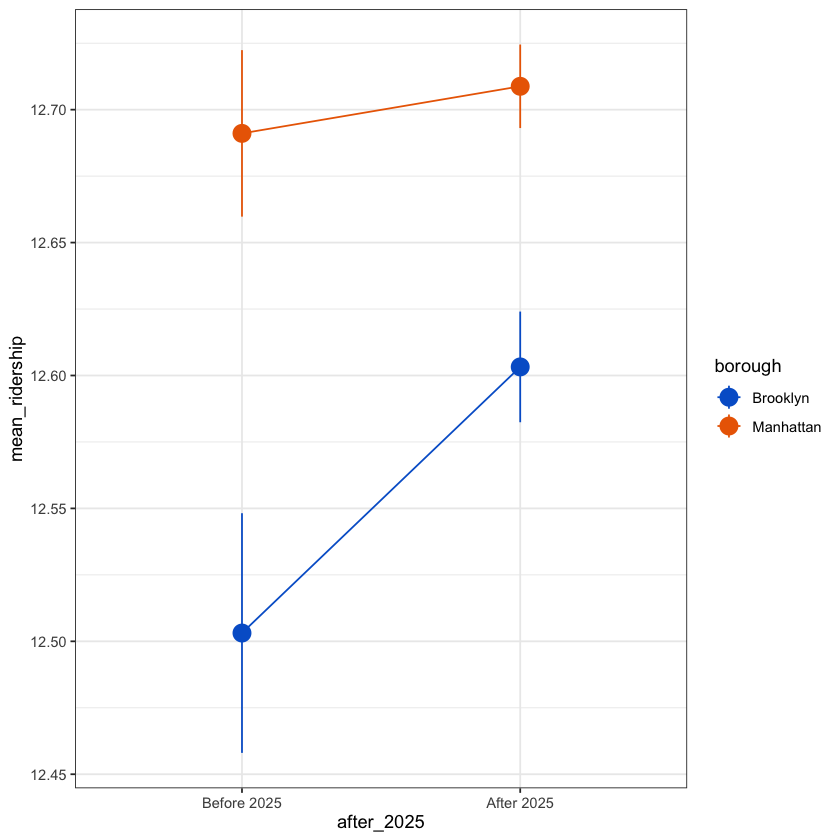

In [106]:
ggplot(plot_data_log, aes(x = after_2025, y = mean_ridership, color = borough)) +
  geom_pointrange(aes(ymin = lower, ymax = upper), size = 1) +
  geom_line(aes(group = borough)) + 
  theme_bw() + 
  scale_color_manual(values = c("Manhattan" = nyc_orange, "Brooklyn" = nyc_blue))

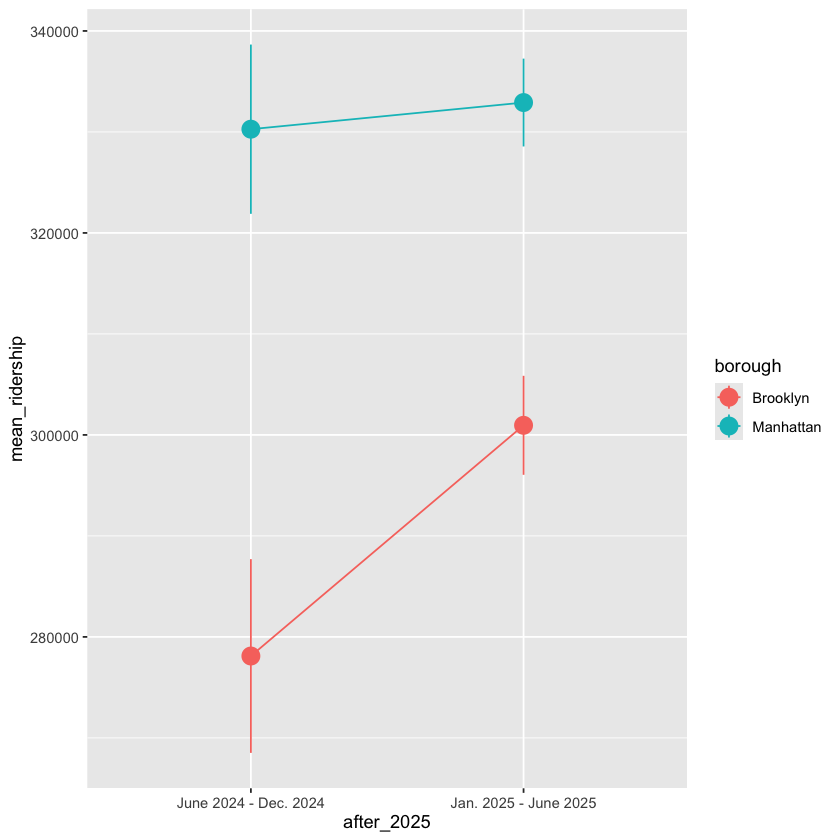

In [107]:
ggplot(plot_data, aes(x = after_2025, y = mean_ridership, color = borough)) +
  geom_pointrange(aes(ymin = lower, ymax = upper), size = 1) +
  geom_line(aes(group = borough))

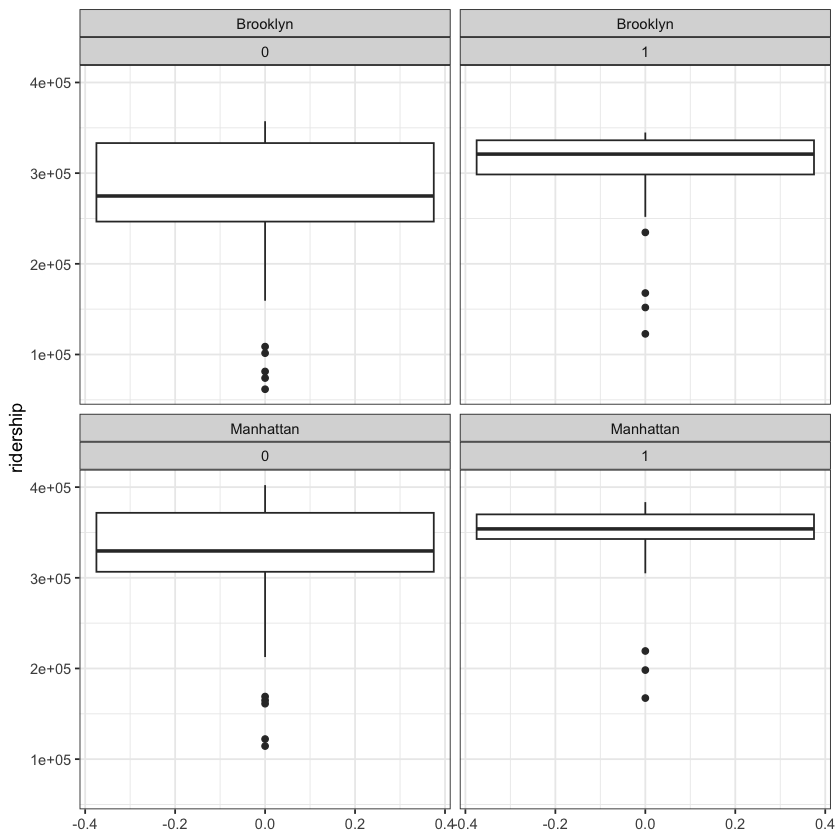

In [108]:
df_daily |> filter(borough == "Manhattan" | borough == "Brooklyn")|>
filter(date < "2025-06-01") |>
ggplot(aes(y = ridership)) + 
    geom_boxplot() + 
    facet_wrap(vars(borough, time)) + 
    theme_bw()